# DG advection with noisy initial data and SIAC postprocessing

In this notebook, we follow the same setup as in the previous notebook, but introduce noise in the initial data before the DG projection. The goal is to investigate how well SIAC postprocessing reduces noise-induced errors when the noise amplitude is scaled with the mesh size.

We consider additive Gaussian noise of magnitude

$$
    \varepsilon = C h^q,
$$

where $h$ is the mesh size, $C$ is a fixed constant, and $q$ is varied. In particular, we test

$$
    q \in \{p+1,\, r+1,\, r+2\},
$$

where $p$ is the DG polynomial degree and $r$ is the enforced polynomial reproduction degree of the SIAC kernel.

The noise is added at the quadrature points during the $L^2$-projection of the exact initial condition. That is, instead of projecting $f$, we project

$$
    f_{\mathrm{noisy}}(x) = f(x) + \varepsilon \eta(x),
$$

where $\eta$ denotes independent standard Gaussian noise, $\eta \sim \mathcal{N}(0,1)$, sampled at the projection quadrature points.

This gives an initial DG approximation of the form

$$
    u_h^0 = \Pi_h f_{\mathrm{noisy}},
$$

which is then evolved with the DG advection solver and postprocessed using SIAC filtering.

In [48]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
sys.path.append(str(PROJECT_ROOT))

In [49]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

from src.mesh import build_uniform_mesh
from src.projection import l2_project_mesh, l2_project_mesh_noisy
from src.dg_solver import dg_rhs_advection
from src.time_integrators import forward_euler_step, rk4_step, time_integrator
from src.cfl import estimate_dt_advection, choose_time_step
from src.evaluation import evaluate_dg_solution
from src.metrics import linf_error, l2_error_dg, relative_l2_error_dg, relative_l2_error_from_grid
from src.siac import apply_siac_to_modal_dg_1d

In [50]:
# Wave speed
a = 2

# Total Time
T = 2

# time stepping method: rk4 or euler (forward_euler)
time_method = "rk4"

# Define the domain
xmin, xmax = -1, 1
domain = (-1, 1)

# DG setup
p = 2
order = p + 1
K = 32

# Exact function (periodic)
def exact_func(x):
    return np.sin(2*np.pi*x)

# create mesh
mesh = build_uniform_mesh(K=K, domain=domain)

# build initial projection
# Test with noise q = p + 1
q = p+1

dg = l2_project_mesh_noisy(f=exact_func, p=p, mesh=mesh, q=q, C=1.0, seed=64, num_quad=None)

# Define RHS wrapper
def rhs(u, t):
    return dg_rhs_advection(
        coeffs=u, 
        mesh=mesh, 
        p=p, 
        a=a
    )

# choose time stepping from CFL conditions
dt_est = estimate_dt_advection(mesh=mesh, p=p, a=a, method=time_method, safety=0.9)
dt, num_steps = choose_time_step(T=T, dt_est=dt_est)

print(f"dt = {dt}")
print(f"num_steps = {num_steps}")



dt = 0.0056179775280898875
num_steps = 356


In [51]:
time_tol = 1e-12

u = dg["coeffs"].copy()
t = 0.0

for n in range(num_steps):
    dt_step = min(dt, T - t)

    if dt_step <= time_tol:
        break

    u = time_integrator(rhs, u, t, dt_step, method=time_method)
    t += dt_step

# Snap final time to T if only roundoff remains
if abs(T - t) <= time_tol:
    t = T
else:
    raise RuntimeError(f"Time stepping stopped at t={t}, not T={T}.")

dg_final = dg.copy()
dg_final["coeffs"] = u
dg_final["t"] = t

In [52]:
# number of evaluation points per element/cell
ppe = 20

eval_grid, U_dg = evaluate_dg_solution(dg_final, points_per_cell=ppe)

t_final = dg_final["t"]

def exact_solution(x, t):
    return exact_func(x - a*t)

U_exact = exact_solution(eval_grid, t_final)

In [53]:
# pointwise Linf using plotting/evaluation grid
err_linf = linf_error(U_dg, U_exact)

# quadrature-based L2 errors
err_l2 = l2_error_dg(dg_final, exact_solution, t=dg_final["t"])
err_l2_rel = relative_l2_error_dg(dg_final, exact_solution, t=dg_final["t"])

print(f"Linf error       = {err_linf:.3e}")
print(f"L2 error         = {err_l2:.3e}")
print(f"Relative L2 error = {err_l2_rel:.3e}")

Linf error       = 1.137e-03
L2 error         = 3.328e-04
Relative L2 error = 3.328e-04


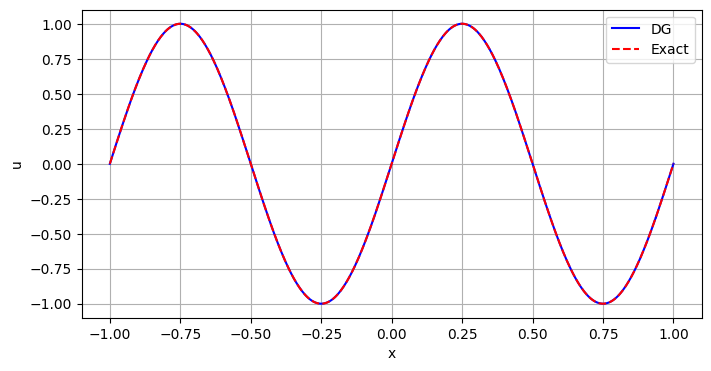

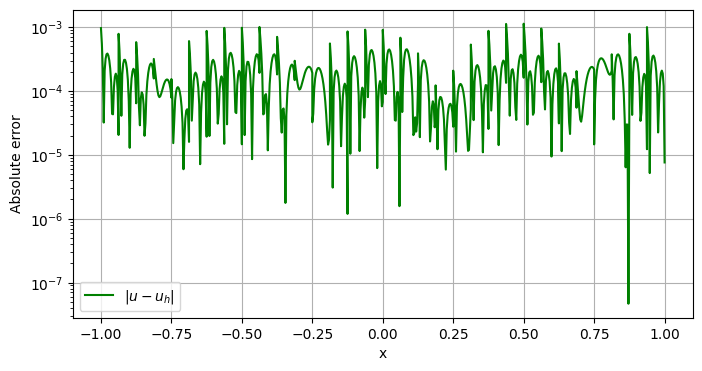

In [54]:
plt.figure(figsize=(8, 4))
plt.plot(eval_grid, U_dg, "b", label="DG")
plt.plot(eval_grid, U_exact, "r--", label="Exact")
plt.xlabel("x")
plt.ylabel("u")
plt.legend()
plt.grid(True)
plt.show()

abs_error = np.abs(U_dg - U_exact)

plt.figure(figsize=(8, 4))
plt.semilogy(eval_grid, abs_error, "g", label=r"$|u-u_h|$")
plt.xlabel("x")
plt.ylabel("Absolute error")
plt.legend()
plt.grid(True)
plt.show()

In [55]:
# Postprocessor
moments = 2*p   # Must be even
BSorder = p+1

U_star = apply_siac_to_modal_dg_1d(dg=dg_final, moments=moments, BSorder=BSorder, points_per_cell=ppe)

In [56]:
# slice all to interior for valid comparison
halfker = int(np.ceil((moments + BSorder) / 2))

# Only valid in interior
start = halfker * ppe
stop = (K - halfker) * ppe

eval_grid_int = eval_grid[start:stop]
U_dg_int = U_dg[start:stop]
U_exact_int = U_exact[start:stop]
U_star_int = U_star[start:stop]

In [57]:

# pointwise Linf using plotting/evaluation grid
err_linf_U = linf_error(U_dg_int, U_exact_int)
err_linf_Ustar = linf_error(U_star_int, U_exact_int)

print(f"Linf error u       = {err_linf_U:.3e}")
print(f"Linf error u_star  = {err_linf_Ustar:.3e}")

Linf error u       = 1.137e-03
Linf error u_star  = 2.262e-04


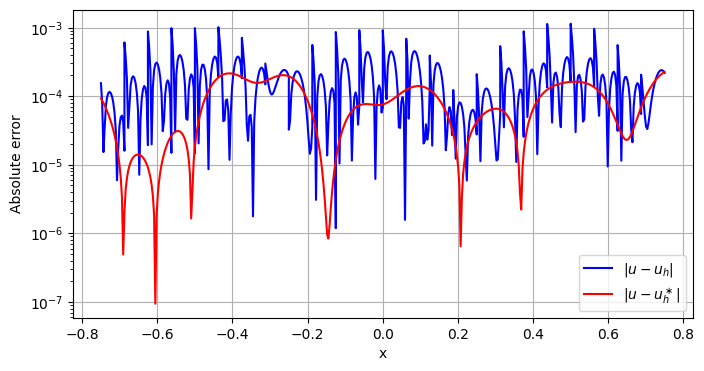

In [58]:
# pointwise error
abs_error_u = np.abs(U_dg_int - U_exact_int)
abs_error_ustar = np.abs(U_star_int - U_exact_int)


plt.figure(figsize=(8, 4))
plt.semilogy(eval_grid_int, abs_error_u, "b", label=r"$|u-u_h|$")
plt.semilogy(eval_grid_int, abs_error_ustar, "r", label=r"$|u-u_h^\ast|$")
plt.xlabel("x")
plt.ylabel("Absolute error")
plt.legend()
plt.grid(True)
plt.show()

### More Experiments

In [59]:
from src.helpers import run_dg_siac_noise_experiment
def exact_func(x):
    return np.sin(2 * np.pi * x)

# Setup
a = 2.0
T = 2.0
time_method="rk4"
domain = (-1.0, 1.0)

# DG
p = 2
K = 32

# Postprocessor (SIAC)
moments = 2*p
BSorder = p + 1

# Noise
q = moments + 1     # noise: O(h^q)
C = 1.0

res = run_dg_siac_noise_experiment(
    exact_func=exact_func,
    a=a,T=T, time_method=time_method, domain=domain,
    p=p, K=K, q=q, C=C, seed=64, ppe=20, 
    moments=moments, BSorder=BSorder
)

err_linf_U = linf_error(
    res["U_dg_int"],
    res["U_exact_int"],
)

err_linf_Ustar = linf_error(
    res["U_star_int"],
    res["U_exact_int"],
)

err_l2 = l2_error_dg(
    res["dg_final"],
    lambda x, t: exact_func(x - res["params"]["a"] * t),
    t=res["t_final"],
)

err_l2_rel = relative_l2_error_dg(
    res["dg_final"],
    lambda x, t: exact_func(x - res["params"]["a"] * t),
    t=res["t_final"],
)

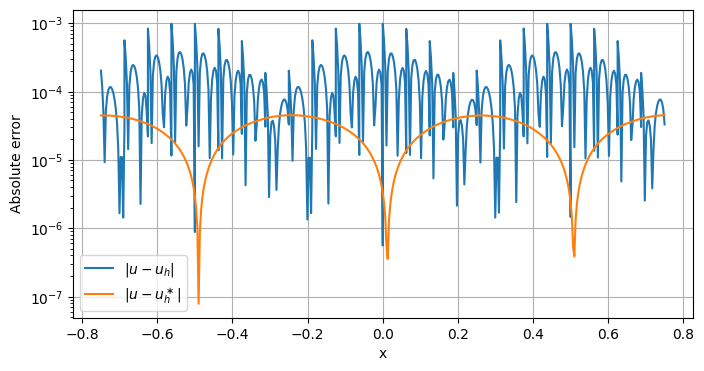

In [60]:
abs_error_u = np.abs(res["U_dg_int"] - res["U_exact_int"])
abs_error_ustar = np.abs(res["U_star_int"] - res["U_exact_int"])

plt.figure(figsize=(8, 4))
plt.semilogy(res["eval_grid_int"], abs_error_u, label=r"$|u-u_h|$")
plt.semilogy(res["eval_grid_int"], abs_error_ustar, label=r"$|u-u_h^\ast|$")
plt.xlabel("x")
plt.ylabel("Absolute error")
plt.legend()
plt.grid(True)
plt.show()

In [61]:
Ks = [16, 32, 64, 128]
qs = [p + 1, 2 * p, 2 * p + 1, 2 * p + 2]  # or [p+1, r, r+1, r+2]

results = {}

for K in Ks:
    for q in qs:
        key = (K, q)

        results[key] = run_dg_siac_noise_experiment(
            exact_func=exact_func,
            a=2.0,
            T=2.0,
            time_method="rk4",
            domain=(-1.0, 1.0),
            p=p,
            K=K,
            q=q,
            C=1.0,
            seed=64,
            ppe=20,
            moments=2 * p,
            BSorder=p + 1,
        )

In [62]:
rows = []

for (K, q), res in results.items():
    err_linf_U = linf_error(
        res["U_dg_int"],
        res["U_exact_int"],
    )

    err_linf_Ustar = linf_error(
        res["U_star_int"],
        res["U_exact_int"],
    )

    rows.append({
        "K": K,
        "h": (res["params"]["domain"][1] - res["params"]["domain"][0]) / K,
        "p": res["params"]["p"],
        "q": q,
        "Linf_DG": err_linf_U,
        "Linf_SIAC": err_linf_Ustar,
    })

error_df = pd.DataFrame(rows)

In [63]:
def plot_pointwise_error_single(res, title=None):
    """
    Plot pointwise interior errors for one DG/SIAC experiment.
    """

    x = res["eval_grid_int"]

    err_dg = np.abs(res["U_dg_int"] - res["U_exact_int"])
    err_siac = np.abs(res["U_star_int"] - res["U_exact_int"])

    params = res["params"]

    if title is None:
        title = (
            rf"$K={params['K']}$, "
            rf"$p={params['p']}$, "
            rf"$q={params['q']}$"
        )

    plt.figure(figsize=(8, 4))
    plt.semilogy(x, err_dg, label=rf"DG: $|u-u_h|$")
    plt.semilogy(x, err_siac, label=rf"SIAC: $|u-u_h^\ast|$")
    plt.xlabel(r"$x$")
    plt.ylabel("Pointwise absolute error")
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.show()

In [64]:
def plot_pointwise_errors_fixed_K(results, K, qs, which="both"):
    """
    Compare pointwise errors for several q values at fixed K.

    Parameters
    ----------
    results : dict
        Dictionary indexed by (K, q).

    K : int
        Fixed number of cells.

    qs : list
        Noise exponents to compare.

    which : str
        "dg", "siac", or "both".
    """

    plt.figure(figsize=(8, 4))

    for q in qs:
        res = results[(K, q)]
        x = res["eval_grid_int"]

        err_dg = np.abs(res["U_dg_int"] - res["U_exact_int"])
        err_siac = np.abs(res["U_star_int"] - res["U_exact_int"])

        if which in ["dg", "both"]:
            plt.semilogy(
                x,
                err_dg,
                linestyle="--",
                label=rf"DG, $q={q}$",
            )

        if which in ["siac", "both"]:
            plt.semilogy(
                x,
                err_siac,
                linestyle="-",
                label=rf"SIAC, $q={q}$",
            )

    p = results[(K, qs[0])]["params"]["p"]

    plt.xlabel(r"$x$")
    plt.ylabel("Pointwise absolute error")
    plt.title(rf"Pointwise errors for fixed $K={K}$, $p={p}$")
    plt.legend()
    plt.grid(True)
    plt.show()

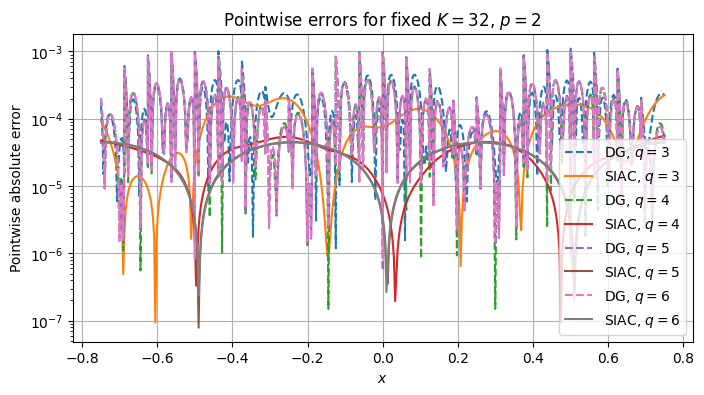

In [65]:
plot_pointwise_errors_fixed_K(
    results=results,
    K=32,
    qs=[3, 4, 5, 6],
    which="both",
)

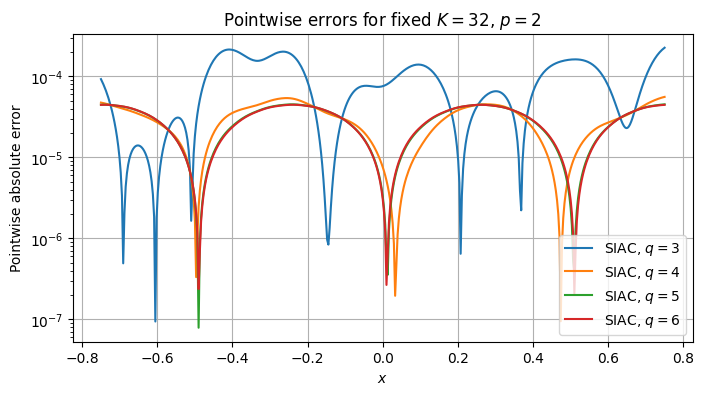

In [66]:
plot_pointwise_errors_fixed_K(
    results=results,
    K=32,
    qs=[3, 4, 5, 6],
    which="siac",
)

In [67]:
def plot_pointwise_errors_fixed_q(results, Ks, q, which="both"):
    """
    Compare pointwise errors for several K values at fixed q.
    """

    plt.figure(figsize=(8, 4))

    for K in Ks:
        res = results[(K, q)]
        x = res["eval_grid_int"]

        err_dg = np.abs(res["U_dg_int"] - res["U_exact_int"])
        err_siac = np.abs(res["U_star_int"] - res["U_exact_int"])

        if which in ["dg", "both"]:
            plt.semilogy(
                x,
                err_dg,
                linestyle="--",
                label=rf"DG, $K={K}$",
            )

        if which in ["siac", "both"]:
            plt.semilogy(
                x,
                err_siac,
                linestyle="-",
                label=rf"SIAC, $K={K}$",
            )

    p = results[(Ks[0], q)]["params"]["p"]

    plt.xlabel(r"$x$")
    plt.ylabel("Pointwise absolute error")
    plt.title(rf"Pointwise errors for fixed $q={q}$, $p={p}$")
    plt.legend()
    plt.grid(True)
    plt.show()

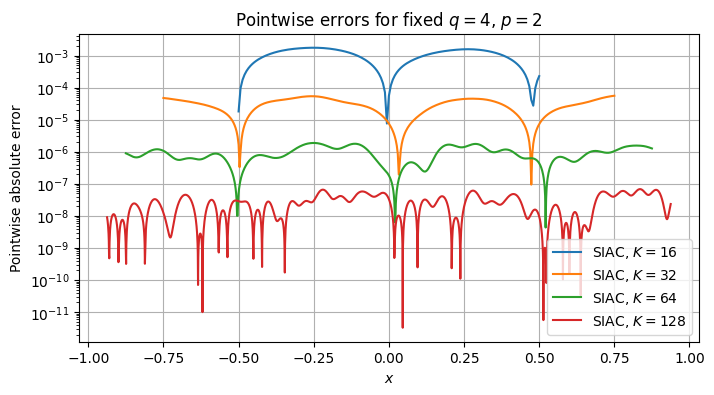

In [71]:
plot_pointwise_errors_fixed_q(
    results=results,
    Ks=[16, 32, 64, 128],
    q=4,
    which="siac",
)

In [69]:
def plot_dg_vs_siac_by_q(results, K, qs):
    """
    For a fixed K, make one subplot per q.
    Each subplot compares DG and SIAC pointwise errors.
    """

    fig, axes = plt.subplots(
        1,
        len(qs),
        figsize=(5 * len(qs), 4),
        sharey=True,
    )

    if len(qs) == 1:
        axes = [axes]

    for ax, q in zip(axes, qs):
        res = results[(K, q)]
        x = res["eval_grid_int"]

        err_dg = np.abs(res["U_dg_int"] - res["U_exact_int"])
        err_siac = np.abs(res["U_star_int"] - res["U_exact_int"])

        ax.semilogy(x, err_dg, linestyle="--", label=rf"DG")
        ax.semilogy(x, err_siac, linestyle="-", label=rf"SIAC")

        ax.set_title(rf"$q={q}$")
        ax.set_xlabel(r"$x$")
        ax.grid(True)

    axes[0].set_ylabel("Pointwise absolute error")
    axes[0].legend()

    p = results[(K, qs[0])]["params"]["p"]
    fig.suptitle(rf"DG vs SIAC pointwise errors, $K={K}$, $p={p}$")
    fig.tight_layout()
    plt.show()

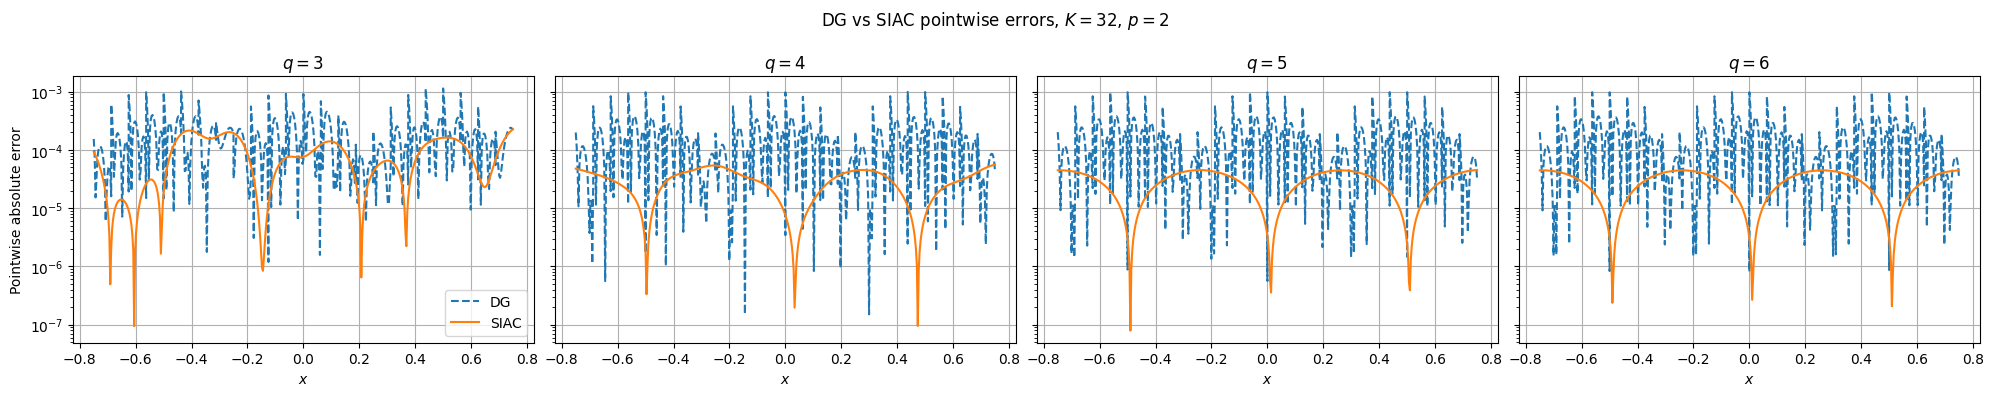

In [70]:
plot_dg_vs_siac_by_q(
    results=results,
    K=32,
    qs=[3, 4, 5, 6],
)